In [1]:
# Data Loading And Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


In [5]:
df = pd.read_csv(r"C:\Users\stran\Desktop\DS\Student Performance analyzer\student_performance_dataset.csv")

print("=== Dataset Overview ===")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()


=== Dataset Overview ===
Shape: (120, 10)

Columns: ['Student_ID', 'Math', 'Physics', 'Chemistry', 'English', 'Computer_Science', 'Attendance_Percent', 'Study_Hours_Per_Day', 'Average_Marks', 'Final_Grade']


,Student_ID,Math,Physics,Chemistry,English,Computer_Science,Attendance_Percent,Study_Hours_Per_Day,Average_Marks,Final_Grade
0,S001,82.00,70.00,42,52,81,69.00,4.50,65.40,C
1,S002,60.00,67.00,56,37,75,82.00,1.70,59.00,C
2,S003,58.00,68.00,54,49,72,57.00,-1.00,60.20,C
3,S004,92.00,80.00,80,81,90,72.00,1.70,84.60,B
4,S005,NaN,NaN,85,66,65,NaN,NaN,72.00,B


In [6]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\n=== Basic Stats ===")
df.describe()


=== Missing Values ===
Student_ID              0
Math                   10
Physics                10
Chemistry               0
English                 0
Computer_Science        0
Attendance_Percent     10
Study_Hours_Per_Day     9
Average_Marks           0
Final_Grade             0
dtype: int64

=== Basic Stats ===


,Math,Physics,Chemistry,English,Computer_Science,Attendance_Percent,Study_Hours_Per_Day,Average_Marks
count,110.00,110.00,120.00,120.00,120.00,110.00,111.00,120.00
mean,68.04,67.78,66.25,67.99,70.53,77.24,2.52,68.34
std,19.37,18.19,18.12,19.65,17.77,16.34,1.54,9.67
min,35.00,35.00,35.00,35.00,40.00,55.00,-1.00,38.60
25%,51.00,51.00,52.00,52.00,55.75,64.00,1.20,60.75
50%,68.50,68.50,68.50,68.50,72.00,75.00,2.70,67.40
75%,84.75,83.00,80.00,85.25,86.00,87.00,3.80,75.75
max,99.00,99.00,99.00,99.00,99.00,120.00,4.90,95.33


In [7]:
print("=== Before Cleaning ===")
print("Negative Study_Hours:", (df["Study_Hours_Per_Day"] < 0).sum())
print("Attendance > 100:", (df["Attendance_Percent"] > 100).sum())

# Fill NaN with column means
for col in ["Math", "Physics", "Attendance_Percent", "Study_Hours_Per_Day"]:
    df[col].fillna(df[col].mean(), inplace=True)
    print(f"Filled NaN in '{col}' with mean = {df[col].mean():.2f}")

# Fix negative study hours → median
median_study = df.loc[df["Study_Hours_Per_Day"] >= 0, "Study_Hours_Per_Day"].median()
df.loc[df["Study_Hours_Per_Day"] < 0, "Study_Hours_Per_Day"] = median_study
print(f"\nFixed negative Study_Hours → median ({median_study:.2f})")

# Cap attendance at 100
df["Attendance_Percent"] = df["Attendance_Percent"].clip(upper=100)
print("Capped Attendance_Percent at 100")

print("\n=== After Cleaning ===")
print("Missing values:", df.isnull().sum().sum())
print("Study_Hours range:", df["Study_Hours_Per_Day"].min(), "–", df["Study_Hours_Per_Day"].max())
print("Attendance range:", df["Attendance_Percent"].min(), "–", df["Attendance_Percent"].max())

df.to_csv("student_performance_cleaned.csv", index=False)
print("\n✅ Saved: student_performance_cleaned.csv")


=== Before Cleaning ===
Negative Study_Hours: 6
Attendance > 100: 6
Filled NaN in 'Math' with mean = 68.04
Filled NaN in 'Physics' with mean = 67.78
Filled NaN in 'Attendance_Percent' with mean = 77.24
Filled NaN in 'Study_Hours_Per_Day' with mean = 2.52

Fixed negative Study_Hours → median (2.65)
Capped Attendance_Percent at 100

=== After Cleaning ===
Missing values: 0
Study_Hours range: 0.5 – 4.9
Attendance range: 55.0 – 100.0

✅ Saved: student_performance_cleaned.csv


In [8]:
# Subject Wise Score Visualization

In [9]:
subjects = ["Math", "Physics", "Chemistry", "English", "Computer_Science"]
grade_colors = {"A": "#2ecc71", "B": "#f39c12", "C": "#e74c3c"}



Text(0.5, 0.98, 'Subject-wise Score Analysis')

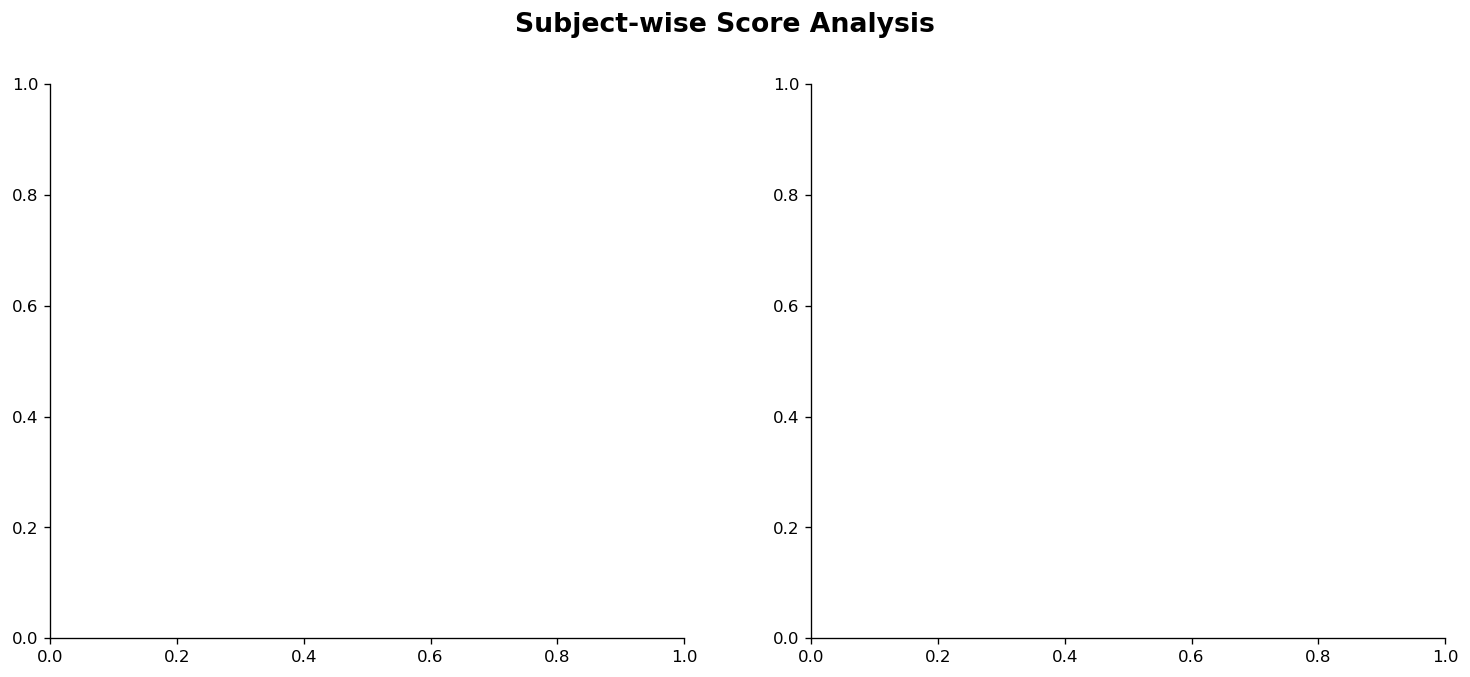

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Subject-wise Score Analysis", fontsize=16, fontweight="bold")



In [11]:
# Average scores bar chart
avg = df[subjects].mean().sort_values()
colors = sns.color_palette("Blues_d", len(subjects))
bars = axes[0].barh(avg.index, avg.values, color=colors, edgecolor="white")
for bar, val in zip(bars, avg.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}", va="center", fontsize=10)
axes[0].set_xlim(0, 110)
axes[0].set_title("Average Marks per Subject")
axes[0].set_xlabel("Average Marks")




Text(0.5, 5.33333333333334, 'Average Marks')

In [13]:
# Box plot — spread per subject
df[subjects].plot(kind="box", ax=axes[1], patch_artist=True,
                  boxprops=dict(facecolor="#4C72B0", alpha=0.6),
                  medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Score Distribution per Subject")
axes[1].set_ylabel("Marks")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
# plt.savefig("plots/01_subject_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: plots/01_subject_scores.png")

<Figure size 768x576 with 0 Axes>

✅ Saved: plots/01_subject_scores.png


In [15]:
# Grade Distribution Analysis

In [16]:
import os
os.makedirs("plots", exist_ok=True)



Text(0.5, 0.98, 'Grade Distribution Analysis')

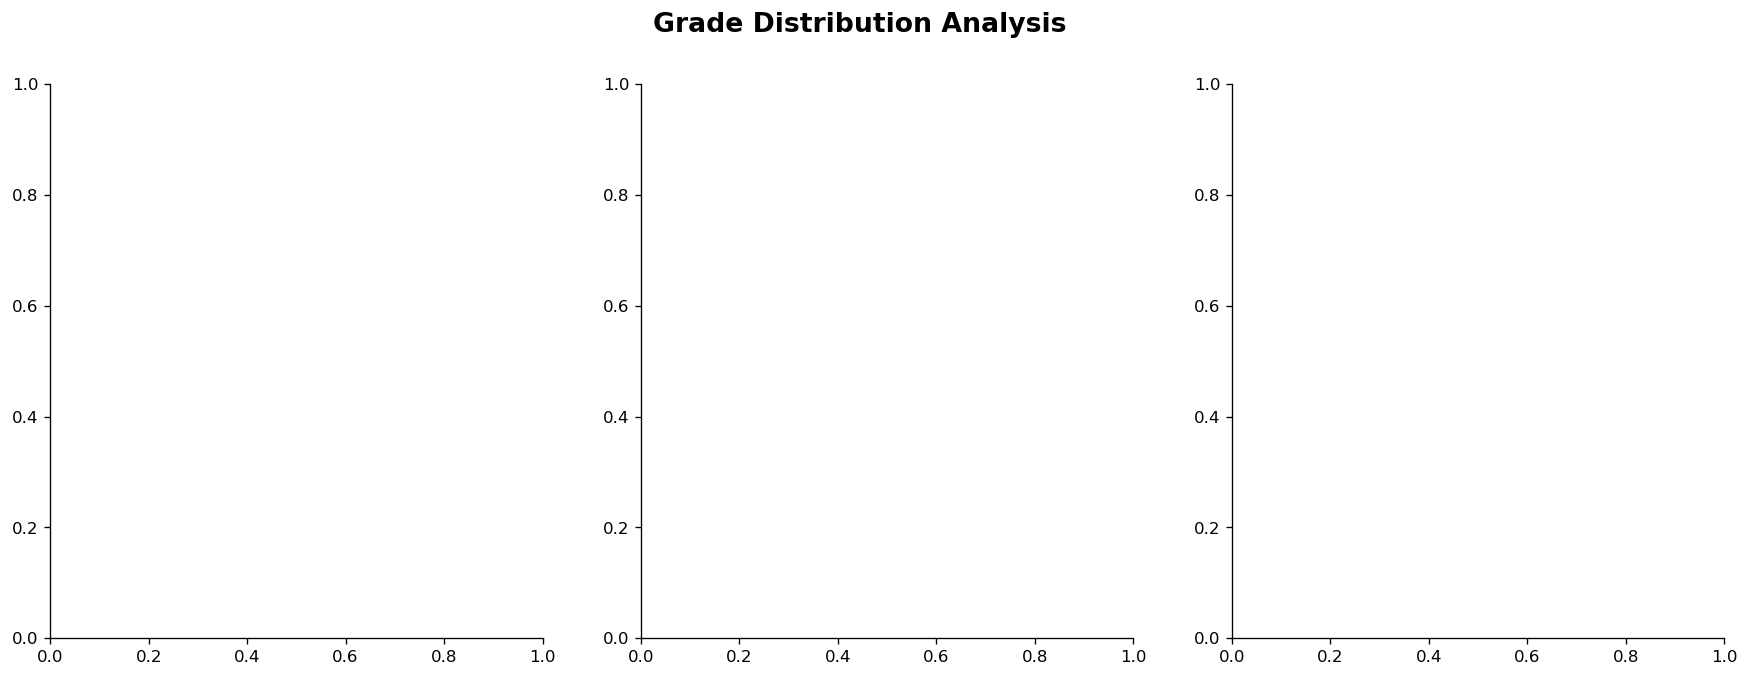

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Grade Distribution Analysis", fontsize=16, fontweight="bold")



In [22]:
# Donut chart
grade_colors = {"A": "#2ecc71", "B": "#f39c12", "C": "#e74c3c", "D": "#9b59b6"}  # ← add D

grade_counts = df["Final_Grade"].value_counts()
axes[0].pie(grade_counts.values, labels=grade_counts.index, autopct="%1.1f%%",
            colors=[grade_colors.get(g, "#95a5a6") for g in grade_counts.index],  # ← .get() as safety net
            startangle=90, wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2))
axes[0].set_title("Grade Split (Donut)")

Text(0.5, 1.0, 'Grade Split (Donut)')

In [23]:
# Count bar
axes[1].bar(grade_counts.index, grade_counts.values,
            color=[grade_colors[g] for g in grade_counts.index],
            edgecolor="white", linewidth=1.2)
for i, (g, v) in enumerate(grade_counts.items()):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontsize=12, fontweight="bold")
axes[1].set_title("Student Count per Grade")
axes[1].set_xlabel("Grade"); axes[1].set_ylabel("Count")



Text(596.1568627450982, 0.5, 'Count')

In [24]:
grade_colors = {"A": "#2ecc71", "B": "#f39c12", "C": "#e74c3c", "D": "#9b59b6"}

In [25]:
# Attendance band vs grade
df["Attendance_Band"] = pd.cut(df["Attendance_Percent"],
    bins=[0, 65, 75, 85, 100], labels=["<65%", "65-75%", "75-85%", "85-100%"])
att_grade = df.groupby(["Attendance_Band", "Final_Grade"]).size().unstack(fill_value=0)
att_grade.plot(kind="bar", ax=axes[2], stacked=True,
               color=[grade_colors[g] for g in att_grade.columns], edgecolor="white")
axes[2].set_title("Attendance Band vs Grade")
axes[2].set_xlabel("Attendance Band"); axes[2].set_ylabel("Student Count")
axes[2].tick_params(axis="x", rotation=15)
axes[2].legend(title="Grade")

plt.tight_layout()
plt.savefig("plots/02_grade_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: plots/02_grade_distribution.png")


<Figure size 768x576 with 0 Axes>

✅ Saved: plots/02_grade_distribution.png


In [26]:
# Correlation Analysis

Text(0.5, 0.98, 'Correlation & Relationship Analysis')

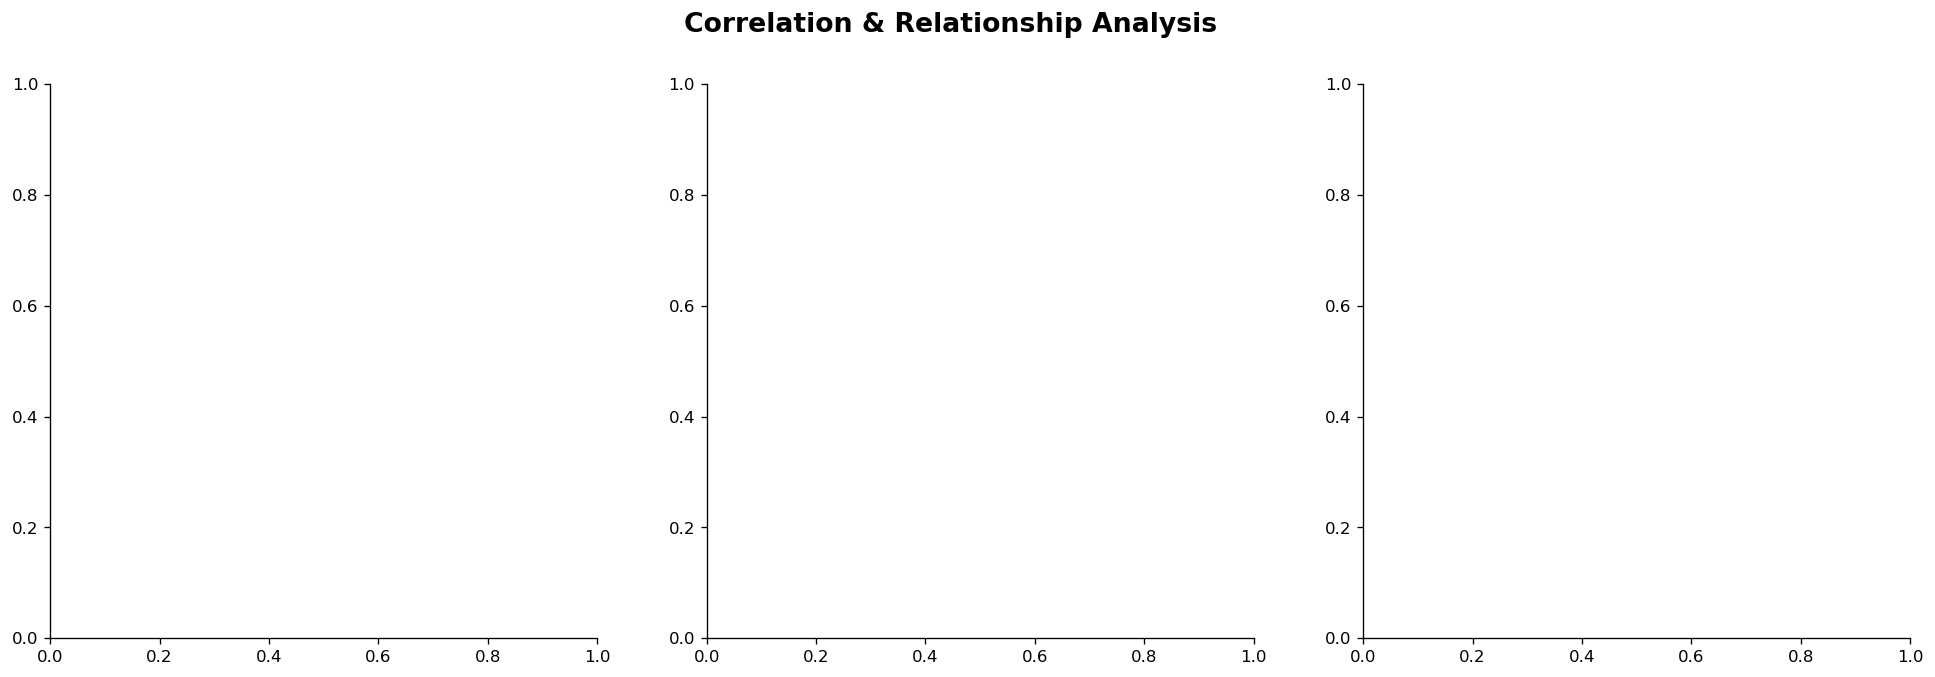

In [27]:
numeric_cols = subjects + ["Attendance_Percent", "Study_Hours_Per_Day", "Average_Marks"]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Correlation & Relationship Analysis", fontsize=16, fontweight="bold")

In [28]:
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[0], linewidths=0.4, annot_kws={"size": 8},
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Correlation Heatmap")
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", rotation=0, labelsize=8)

In [29]:
# Study Hours vs Avg Marks
for grade, grp in df.groupby("Final_Grade"):
    axes[1].scatter(grp["Study_Hours_Per_Day"], grp["Average_Marks"],
                    label=f"Grade {grade}", color=grade_colors[grade],
                    alpha=0.75, s=55, edgecolors="white", linewidths=0.4)
z = np.polyfit(df["Study_Hours_Per_Day"], df["Average_Marks"], 1)
x_line = np.linspace(df["Study_Hours_Per_Day"].min(), df["Study_Hours_Per_Day"].max(), 100)
axes[1].plot(x_line, np.poly1d(z)(x_line), "k--", alpha=0.4, label="Trend")
axes[1].set_title(f"Study Hours vs Avg Marks\n(r = {df['Study_Hours_Per_Day'].corr(df['Average_Marks']):.2f})")
axes[1].set_xlabel("Study Hours / Day"); axes[1].set_ylabel("Average Marks")
axes[1].legend()

In [30]:
# Attendance vs Avg Marks
for grade, grp in df.groupby("Final_Grade"):
    axes[2].scatter(grp["Attendance_Percent"], grp["Average_Marks"],
                    label=f"Grade {grade}", color=grade_colors[grade],
                    alpha=0.75, s=55, edgecolors="white", linewidths=0.4)
z2 = np.polyfit(df["Attendance_Percent"], df["Average_Marks"], 1)
x2 = np.linspace(df["Attendance_Percent"].min(), df["Attendance_Percent"].max(), 100)
axes[2].plot(x2, np.poly1d(z2)(x2), "k--", alpha=0.4, label="Trend")
axes[2].set_title(f"Attendance vs Avg Marks\n(r = {df['Attendance_Percent'].corr(df['Average_Marks']):.2f})")
axes[2].set_xlabel("Attendance %"); axes[2].set_ylabel("Average Marks")
axes[2].legend()

plt.tight_layout()
plt.savefig("plots/03_correlation_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: plots/03_correlation_analysis.png")

<Figure size 768x576 with 0 Axes>

✅ Saved: plots/03_correlation_analysis.png
